In [52]:
import numpy as np
import json
import matplotlib.pyplot as plt
import os

import cobra
import pandas as pd
import pickle

In [2]:
# Load the model
# Path relative to this notebook
model = cobra.io.read_sbml_model("../../model.xml")

In [6]:
# Load the media definitions
# Path relative to this notebook
with open("../../test/test_files/media/media_definitions.pkl", "rb") as f:
    media_definitions = pickle.load(f)

In [8]:
# Set the model's medium to the minimal glucose medium
model.medium = media_definitions["minimal_glucose"]

In [21]:
# Define the ED reaction ID
ed_rxn = model.reactions.rxn01477_c0
# Define the biomass reaction ID
biomass_rxn = "bio1_biomass"
# Define a reaction to indicate flux through the EMP
emp_rxn = model.reactions.rxn00558_c0

In [81]:
# For a range of ED use values, optimize the model and record the growth rate
ed_use = np.linspace(0, 10, 11)
results = []
# For both my "real" O2 (20) and "infinite" O2 (1000)
for o2 in [20, 1000]:
    # Set the O2 uptake rate
    model.reactions.EX_cpd00007_e0.lower_bound = -o2
    for use in ed_use:
        # Set the ED use by constraining the lower bound of the key ED reaction
        ed_rxn.lower_bound = use
        # Run pFBA
        sol = cobra.flux_analysis.pfba(model)
        # Save results
        results_dict = {
            "o2": o2,
            "ed_use": use,
            "ed_percent": sol.fluxes[ed_rxn.id] / (sol.fluxes[ed_rxn.id] + sol.fluxes[emp_rxn.id]) * 100,
            "fluxes": sol.fluxes,
            "growth_rate": sol.fluxes[biomass_rxn],
            "cue" : 1 - (sol.fluxes["EX_cpd00011_e0"] / abs(sol.fluxes["EX_cpd00027_e0"] * 6))
        }
        results.append(results_dict)
    # Convert results to a dataframe
    results_df = pd.DataFrame(results)

In [82]:
results_df

,o2,ed_use,ed_percent,fluxes,growth_rate,cue
0,20,0.0,0.0,rxn02201_c0 5.184579e-03 rxn00351_c0 0.0...,0.805539,0.619394
1,20,1.0,10.0,rxn02201_c0 0.005133 rxn00351_c0 0.000...,0.797484,0.619866
2,20,2.0,20.0,rxn02201_c0 0.005081 rxn00351_c0 0.000...,0.789428,0.620339
3,20,3.0,30.0,rxn02201_c0 0.005029 rxn00351_c0 0.000...,0.781373,0.620812
4,20,4.0,40.0,rxn02201_c0 0.004977 rxn00351_c0 0.000...,0.773317,0.621285
5,20,5.0,50.0,rxn02201_c0 0.004925 rxn00351_c0 0.000...,0.765262,0.621757
6,20,6.0,60.0,rxn02201_c0 0.004874 rxn00351_c0 0.000...,0.757207,0.622230
7,20,7.0,70.0,rxn02201_c0 0.004822 rxn00351_c0 0.000...,0.749151,0.622703
8,20,8.0,80.0,rxn02201_c0 0.004770 rxn00351_c0 0.000...,0.741096,0.623176
9,20,9.0,90.0,rxn02201_c0 0.004718 rxn00351_c0 0.000...,0.733040,0.623648


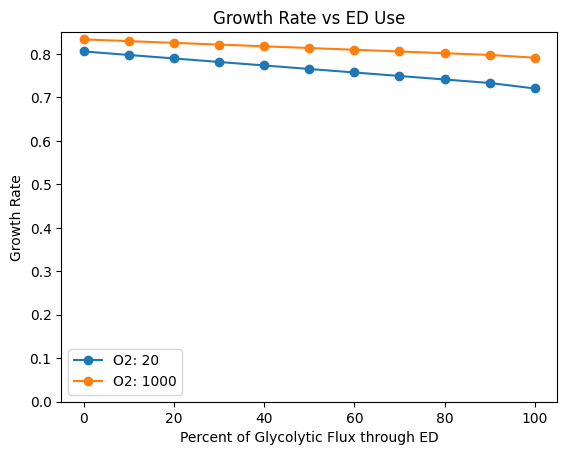

In [85]:
# Plot growth rate vs ed use
# Group by O2 level and plot different color lines for each
for o2_level in results_df["o2"].unique():
    subset = results_df[results_df["o2"] == o2_level]
    plt.plot(subset["ed_percent"], subset["growth_rate"], marker="o", label=f"O2: {o2_level}")

# Style the plot
plt.xlabel("Percent of Glycolytic Flux through ED")
plt.ylabel("Growth Rate")
plt.title("Growth Rate vs ED Use")
plt.legend()

# Save
plt.savefig("results/growth_rate_vs_ed_use.png")

# Set the y axis min to be 0, and save again
plt.ylim(0, 0.85)
plt.savefig("results/growth_rate_vs_ed_use_full_range.png")

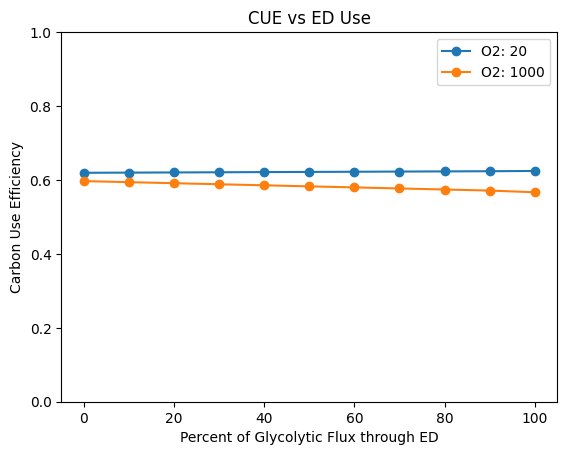

In [86]:
# Plot CUE vs ed use
# Group by O2 level and plot different color lines for each
for o2_level in results_df["o2"].unique():
    subset = results_df[results_df["o2"] == o2_level]
    plt.plot(subset["ed_percent"], subset["cue"], marker="o", label=f"O2: {o2_level}")

# Style the plot and save
plt.legend()
plt.xlabel("Percent of Glycolytic Flux through ED")
plt.ylim(0, 1)
plt.ylabel("Carbon Use Efficiency")
plt.title("CUE vs ED Use")
plt.savefig("results/cue_vs_ed_use.png")

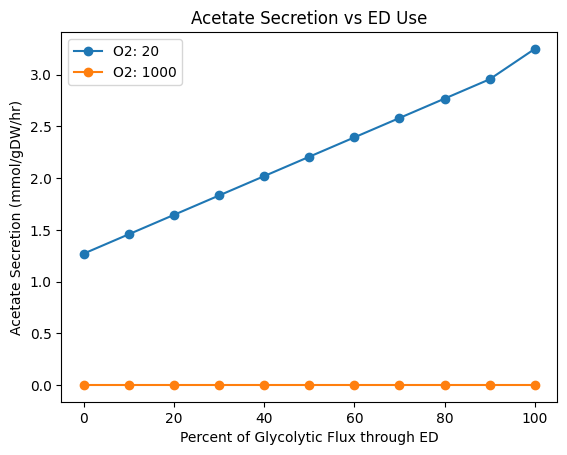

In [87]:
# Plot acetate secretion vs ed use
# Group by O2 level and plot different color lines for each
for o2_level in results_df["o2"].unique():
    subset = results_df[results_df["o2"] == o2_level]
    plt.plot(subset["ed_percent"], subset["fluxes"].apply(lambda x: x.get("EX_cpd00029_e0")), marker="o", label=f"O2: {o2_level}")

# Style the plot and save
plt.legend()
plt.xlabel("Percent of Glycolytic Flux through ED")
plt.ylabel("Acetate Secretion (mmol/gDW/hr)")
plt.title("Acetate Secretion vs ED Use")
plt.savefig("results/acetate_secretion_vs_ed_use.png")

In [88]:
# Make a directory to save the fluxes if it doesn't exist
if not os.path.exists("results/fluxes"):
    os.makedirs("results/fluxes")

# Save all of the fluxes as json files
for i, row in results_df.iterrows():
    fluxes = row["fluxes"].to_dict()
    with open(f"results/fluxes/fluxes_ed_{row['ed_use']}_o2_{row['o2']}.json", "w") as f:
        json.dump(fluxes, f)

# Manually make and save escher maps using the web version